# Rock, Paper, Scissors Classification Model
- 3 classes/poses: rock, paper, scissors
  - 1 sample has 5 * 6  features (for now)?
- Classification neural net

https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/02_pytorch_classification.ipynb#scrollTo=Z2gcR31aHC78

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn

In [2]:
print(torch.__version__)
print(torch._dynamo.__file__)

2.6.0+cu124
/mnt/c/Users/j15t3/Documents/Programming/Capstone/.venv/lib/python3.12/site-packages/torch/_dynamo/__init__.py


## Ablation

https://docs.google.com/spreadsheets/d/1Xy92hWhrxcyvLkxY7Q0RPff1FNVfsLxV0ujrjC6SdFE/edit?gid=427952541#gid=427952541

In [3]:
EPOCHS = 500
STD = 0.03
COPY = 4
HIDDEN = 0 # No consistent hidden layers in other models
DROPOUT = 0.5

N_FOLDS = 5

In [33]:
# os.chdir("/content/drive/MyDrive/Senior/Capstone/new data")
df = pd.read_csv("data/Glove_v2/ALL_RPSdata_V2.csv")
# df = pd.read_csv("jag_RPS_training_data.csv")
df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21378 entries, 0 to 21377
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       21378 non-null  float64
 1   1       21378 non-null  float64
 2   2       21378 non-null  float64
 3   3       21378 non-null  float64
 4   4       21378 non-null  float64
 5   5       21378 non-null  float64
 6   6       21378 non-null  float64
 7   7       21378 non-null  float64
 8   8       21378 non-null  float64
 9   9       21378 non-null  float64
 10  10      21378 non-null  float64
 11  11      21378 non-null  float64
 12  12      21378 non-null  float64
 13  13      21378 non-null  float64
 14  14      21378 non-null  float64
 15  15      21378 non-null  float64
 16  16      21378 non-null  float64
 17  17      21378 non-null  float64
 18  18      21378 non-null  float64
 19  19      21378 non-null  float64
 20  20      21378 non-null  float64
 21  21      21378 non-null  float64
 22  22      2

In [34]:
def augment_with_noise(df, label_col="label", noise_std=0.01, copies=3):
    feature_cols = df.drop(columns=[label_col]).columns
    augmented_dfs = [df]  # keep original

    for i in range(copies):

        noisy_df = df.copy()

        noise = np.random.normal(
            loc=0,
            scale=noise_std,
            size=noisy_df[feature_cols].shape
        )

        noisy_df[feature_cols] = noisy_df[feature_cols] + noise

        augmented_dfs.append(noisy_df)

    return pd.concat(augmented_dfs, ignore_index=True)

In [35]:
augmented_df = augment_with_noise(
    df,
    label_col="label",
    noise_std=STD,   # adjust noise strength
    copies=COPY
)

print(len(df))
df = augmented_df
print(len(augmented_df))

21378
106890


In [36]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,0.000000e+00,0.430877,0.401365,0.534408,0.462630,0.609432,0.409276,0.876979,0.592220,0.854043,...,0.577344,0.653058,0.535044,0.423435,0.584591,0.346361,0.597167,0.680255,0.539642,paper
1,5.561842e-07,0.466638,0.398723,0.485254,0.463812,0.627442,0.400306,0.883069,0.568075,0.853617,...,0.579532,0.652382,0.533586,0.420772,0.585668,0.351739,0.598370,0.679270,0.537704,paper
2,1.083846e-06,0.466638,0.398723,0.485254,0.466414,0.589438,0.422346,0.898295,0.544601,0.844681,...,0.580136,0.652182,0.531363,0.427430,0.586207,0.354249,0.598391,0.679523,0.534287,paper
3,1.240719e-05,0.521151,0.395421,0.517499,0.466887,0.591728,0.424909,0.896468,0.535211,0.853617,...,0.580024,0.652421,0.530489,0.429649,0.587284,0.358910,0.597320,0.680151,0.534324,paper
4,1.288493e-05,0.521151,0.393439,0.514353,0.467124,0.591422,0.424909,0.905603,0.551308,0.857447,...,0.580248,0.650471,0.530234,0.430093,0.585129,0.356042,0.596032,0.678454,0.533946,paper


In [37]:
# 1. Get your minimum count
min_count = df['label'].value_counts().min()

# 2. Use groupby + sample directly (much more reliable)
df_balanced = (
    df.groupby('label', group_keys=False)
    .sample(n=min_count, random_state=42)
)

# 3. Reset index at the very end
df_balanced = df_balanced.reset_index(drop=True)

# Now this will work
print(df_balanced['label'].value_counts())
df = df_balanced

label
paper       32170
rock        32170
scissors    32170
Name: count, dtype: int64


In [38]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,-0.003205,0.501091,0.335022,0.507172,0.446799,0.565922,0.369855,0.905893,0.586179,0.864361,...,0.549198,0.679890,0.531424,0.397612,0.542325,0.306006,0.582883,0.631234,0.537001,paper
1,0.135007,0.527140,0.390084,0.508761,0.477975,0.518484,0.444805,0.854448,0.386046,0.858279,...,0.603648,0.674156,0.539628,0.430982,0.645432,0.360134,0.635818,0.635068,0.558218,paper
2,0.220999,0.565595,0.363425,0.528917,0.432198,0.596447,0.456721,0.725746,0.206108,0.771835,...,0.544342,0.627923,0.552582,0.404161,0.677420,0.347889,0.605496,0.644039,0.543997,paper
3,0.146687,0.373679,0.391021,0.529074,0.435501,0.622965,0.460758,0.866584,0.836641,0.795342,...,0.598786,0.646279,0.599843,0.394972,0.602845,0.306653,0.638197,0.696543,0.521978,paper
4,0.272783,0.527163,0.411486,0.681601,0.476867,0.562247,0.445179,0.833279,0.530694,0.240665,...,0.647779,0.672728,0.518414,0.307564,0.642219,0.251840,0.623936,0.724733,0.493596,paper


In [39]:
# testing = df.sample(n=1000)
testing = df.sample(n=1000, random_state=42).sort_values(by='label').reset_index(drop=True)
df      = df.drop(testing.index).reset_index(drop=True)
testing = testing.reset_index(drop=True)

print(f"testing: {testing.shape}")
print(f"df:      {df.shape}")

testing: (1000, 50)
df:      (95510, 50)


In [40]:
df_all = df
df_all.label.value_counts()

label
rock        32170
scissors    32170
paper       31170
Name: count, dtype: int64

## Make data and label dfs


In [41]:
# Scramble the rows
df_all = df_all.sample(frac=1).reset_index(drop=True)
# df_all = df_all.drop(columns=["time"])
df_all.head(3)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,label
0,0.541507,0.374099,0.424156,0.572667,0.561201,0.516319,0.433346,0.763763,0.710085,0.827499,...,0.510171,0.629587,0.612837,0.432598,0.504042,0.594341,0.579816,0.698202,0.576102,rock
1,0.405432,0.403724,0.273579,0.479734,0.540261,0.556652,0.385722,0.940299,0.749532,0.796056,...,0.583751,0.690215,0.456320,0.444648,0.659786,0.537222,0.566612,0.667726,0.464185,scissors
2,0.020171,0.371566,0.373184,0.757766,0.416272,0.491301,0.461558,0.794153,0.737760,0.725106,...,0.471077,0.628427,0.497139,0.350200,0.477909,0.313015,0.493422,0.647510,0.580649,rock


In [42]:
# # Drop all gyro data
# gyro_cols = [col for col in df_all.columns if "gyro" in col]
# df_all = df_all.drop(columns=gyro_cols)
# # leaves you with 18 features (6 sensors × 3 axes)

In [43]:
labels = df_all["label"] # separate labels df, encode labels
mapping = {'rock': 0, 'paper': 1, 'scissors': 2}
labels = labels.map(mapping)
data = df_all.drop(columns=["label"])

In [44]:
# data into pytorch tensors
X = torch.from_numpy(data.values).type(torch.float)
y = torch.from_numpy(labels.values).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Model

In [45]:
input_features = data.shape[1]
classes = 3 # 3 or 4
hidden_units = HIDDEN
input_features

49

In [46]:
# # MODEL 1
# class RPSModel(nn.Module):
#     def __init__(self, input_features, output_features):
#         super().__init__()
#         self.linear_layer_stack = nn.Sequential(
#             nn.Linear(in_features=input_features, out_features=hidden_units),
#             nn.Dropout(p=DROPOUT), # dropout probability
#             # nn.ReLU(),
#             # nn.Linear(in_features=32, out_features=32),
#             # nn.ReLU(),
#             nn.Linear(in_features=hidden_units, out_features=output_features),
#         )

#     # 3. Define a forward method containing the forward pass computation
#     def forward(self, x):
#         return self.linear_layer_stack(x)

In [47]:
# # MODEL 2
# class RPSModel(nn.Module):
#     def __init__(self, input_features, output_features):
#         super().__init__()
#         self.linear_layer_stack = nn.Sequential(
#             nn.Linear(in_features=input_features, out_features=64),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Dropout(p=DROPOUT),
#             nn.Linear(in_features=64, out_features=32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(p=DROPOUT),

#             nn.Linear(in_features=32, out_features=3)
#         )

#     # 3. Define a forward method containing the forward pass computation
#     def forward(self, x):
#         return self.linear_layer_stack(x)

In [48]:
# MODEL 3
class RPSModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=32),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=16, out_features=3)
        )

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        return self.linear_layer_stack(x)

In [49]:
# 4. Create an instance of the model and send it to target device
model_4 = RPSModel(input_features=input_features,
                    output_features=classes).to(device)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

#Training

In [50]:
# Generate a random integer between 1 and 100 (inclusive)
random_integer = random.randint(1, 100)
print(f"Random integer: {random_integer}")

Random integer: 95


In [51]:
torch.manual_seed(24)

epochs = EPOCHS

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

y_train = y_train.long()
y_test = y_test.long()

# Track losses
train_losses, test_losses = [], []

for epoch in range(epochs):
    ### Training
    model_4.train()
    y_logits = model_4(X_train)
    y_pred = torch.argmax(y_logits, dim=1)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Record losses
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.10667, Accuracy: 32.51% | Test loss: 1.10384, Test acc: 32.97%
Epoch: 10 | Loss: 1.09909, Accuracy: 34.55% | Test loss: 1.09654, Test acc: 32.97%
Epoch: 20 | Loss: 1.09312, Accuracy: 38.46% | Test loss: 1.09146, Test acc: 33.04%
Epoch: 30 | Loss: 1.08814, Accuracy: 39.32% | Test loss: 1.08378, Test acc: 52.98%
Epoch: 40 | Loss: 1.08214, Accuracy: 40.72% | Test loss: 1.07347, Test acc: 81.12%
Epoch: 50 | Loss: 1.07554, Accuracy: 42.00% | Test loss: 1.06472, Test acc: 82.20%
Epoch: 60 | Loss: 1.06578, Accuracy: 44.62% | Test loss: 1.05340, Test acc: 75.66%
Epoch: 70 | Loss: 1.05373, Accuracy: 47.16% | Test loss: 1.03778, Test acc: 75.10%
Epoch: 80 | Loss: 1.03690, Accuracy: 50.39% | Test loss: 1.01631, Test acc: 75.68%
Epoch: 90 | Loss: 1.01458, Accuracy: 52.98% | Test loss: 0.98758, Test acc: 75.88%
Epoch: 100 | Loss: 0.98613, Accuracy: 55.23% | Test loss: 0.94978, Test acc: 76.55%
Epoch: 110 | Loss: 0.94903, Accuracy: 57.73% | Test loss: 0.90226, Test acc: 77.73%
Epo

In [63]:
MODEL_PATH = "model_4_weights.pth"
torch.save(model_4.state_dict(), MODEL_PATH)


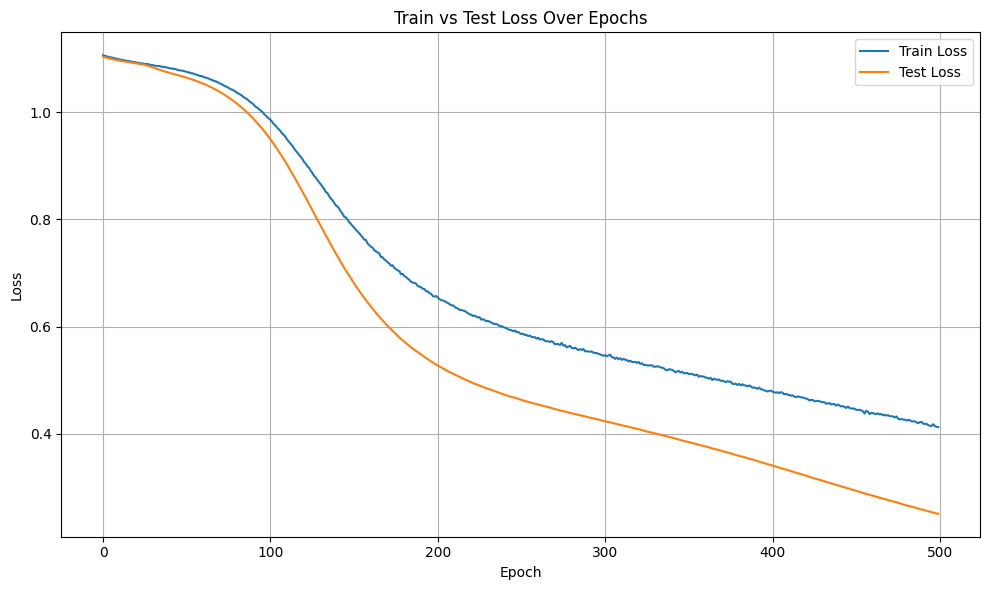

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Testing

In [54]:
testing["label"] = testing["label"].map(mapping)

cmap = plt.cm.get_cmap("gist_rainbow")
num_classes = len(mapping)
colors = cmap(np.linspace(0,1, len(labels)))
labels = ["Rock", "Paper", "Scissors"]

conf_thres = .7

/tmp/ipykernel_24853/1810967289.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("gist_rainbow")


In [55]:
# # Separate features and labels
true_labels = testing['label']
X_features = testing.copy()

X_features = X_features.drop(columns=['label']) # Drop label first

# Ensure all columns are numeric, coercing errors to NaN and filling NaNs with 0
for col in X_features.columns:
    X_features[col] = pd.to_numeric(X_features[col], errors='coerce')
X_features = X_features.fillna(0)

# Align columns with the training data's features
# This step should now work as X_features will have 39 columns (including gyro columns),
# matching the number of columns in `data`.
X_features = X_features[data.columns]

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# Inference
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_pred = torch.argmax(new_logits, dim=1)
    new_probs = torch.softmax(new_logits, dim=1)

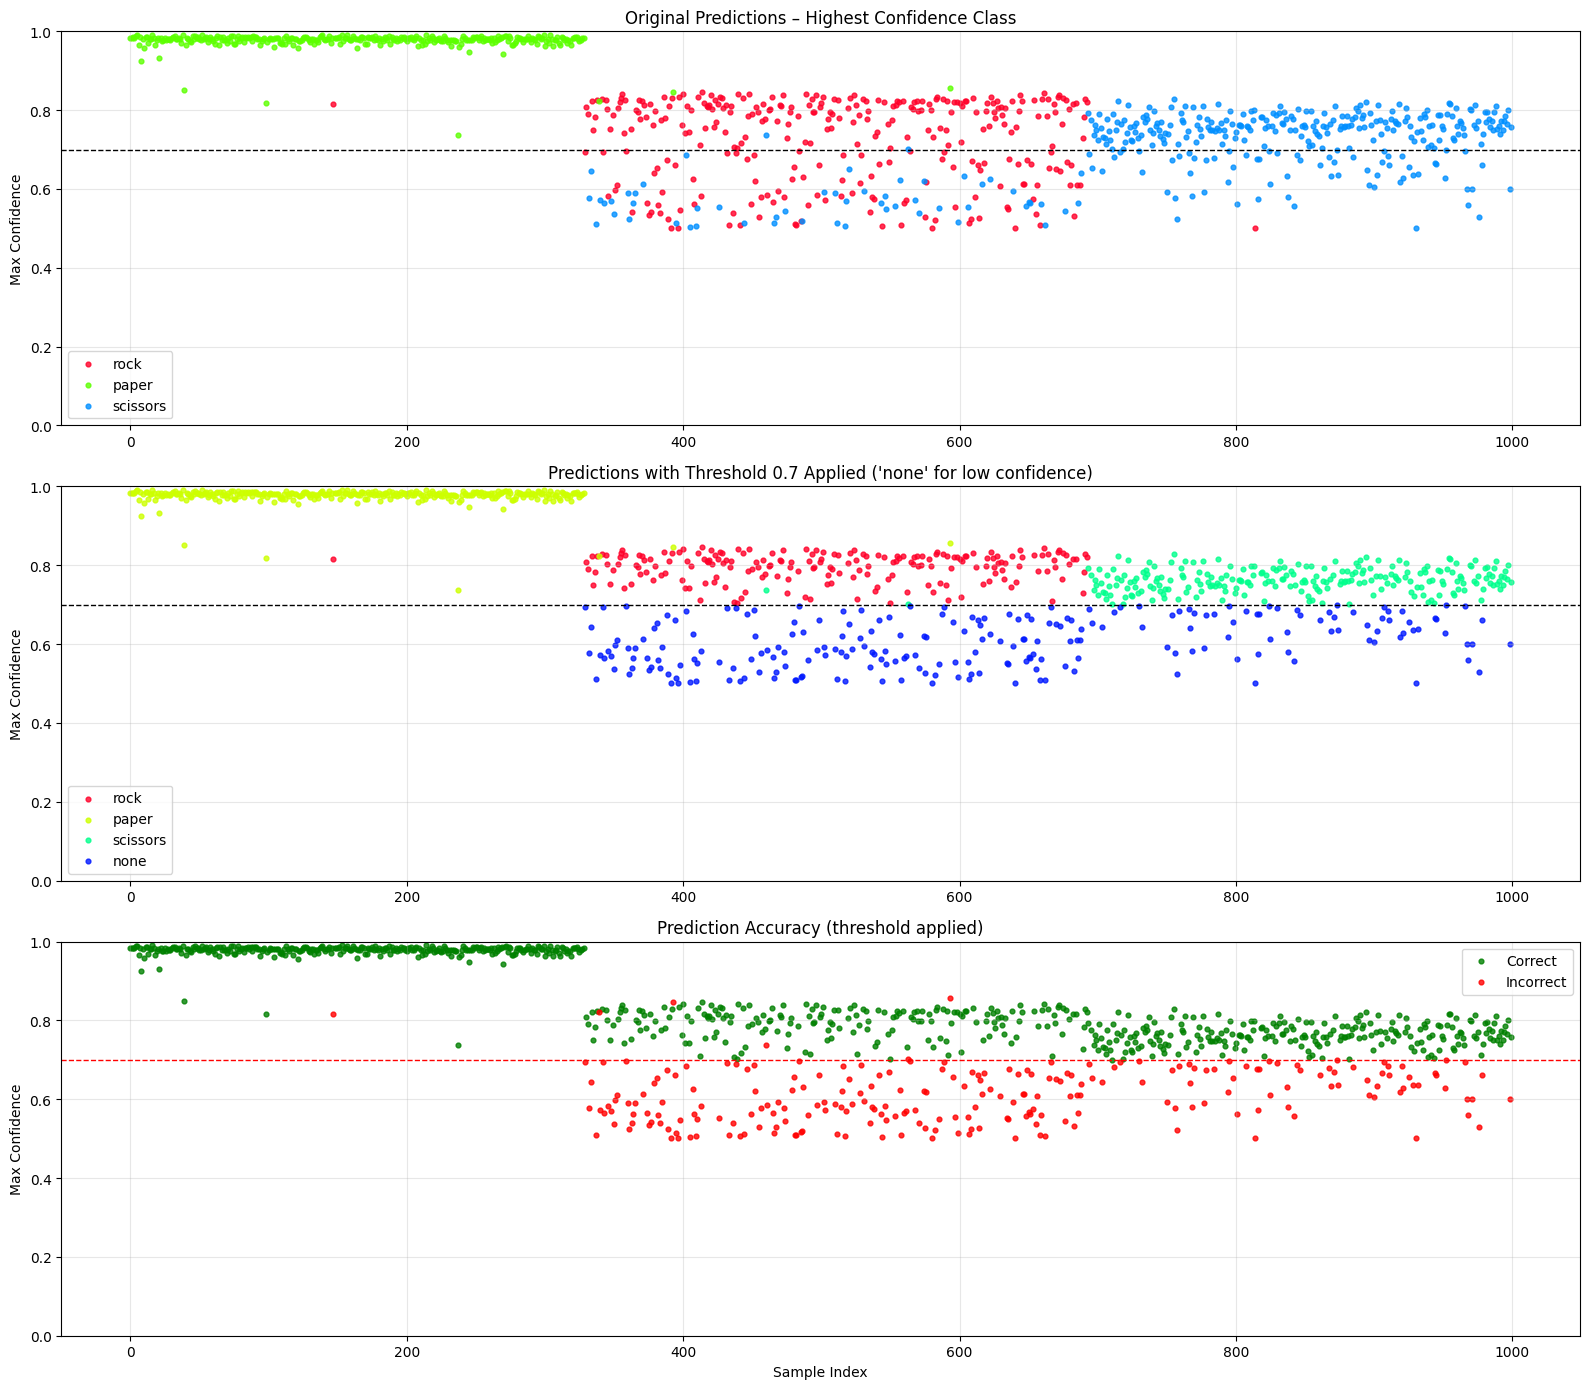

In [56]:
# ------------------------
# Prepare thresholded predictions
# ------------------------
# Convert tensors to CPU numpy
max_probs, max_classes = torch.max(new_probs, dim=1)
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy()
true_numeric = true_labels.reset_index(drop=True).values

pred_classes_thresh = max_classes.copy()
none_class_idx = len(mapping)  # new class index for "none"
pred_classes_thresh[max_probs < conf_thres] = none_class_idx

all_labels = list(mapping.keys()) + ['none']
num_classes = len(all_labels)

# ------------------------
# Create 3 subplots
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16,14))

# ------------------------
# Plot 1: Original max_classes (old graph)
# ------------------------
for class_idx, label in enumerate(mapping.keys()):
    mask = max_classes == class_idx
    indices = np.flatnonzero(mask)
    if len(indices) == 0:
        continue
    color = cmap(class_idx / len(mapping))
    ax1.scatter(
        indices,
        max_probs[indices],
        s=12,
        alpha=0.8,
        label=label,
        color=color
    )

ax1.set_ylabel("Max Confidence")
ax1.set_ylim(0,1)
ax1.set_title("Original Predictions – Highest Confidence Class")
ax1.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax1.legend()
ax1.grid(alpha=0.3)

# ------------------------
# Plot 2: Thresholded predictions (low confidence -> 'none')
# ------------------------
for class_idx, label in enumerate(all_labels):
    mask = pred_classes_thresh == class_idx
    indices = np.flatnonzero(mask)
    if len(indices) == 0:
        continue
    color = cmap(class_idx / num_classes)
    ax2.scatter(
        indices,
        max_probs[indices],
        s=12,
        alpha=0.8,
        label=label,
        color=color
    )

ax2.set_ylabel("Max Confidence")
ax2.set_ylim(0,1)
ax2.set_title(f"Predictions with Threshold {conf_thres} Applied ('none' for low confidence)")
ax2.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

# ------------------------
# Plot 3: Correct vs Incorrect (threshold applied)
# ------------------------
correct_mask_thresh = pred_classes_thresh == true_numeric
incorrect_mask_thresh = pred_classes_thresh != true_numeric

correct_idx = np.flatnonzero(correct_mask_thresh)
incorrect_idx = np.flatnonzero(incorrect_mask_thresh)

ax3.scatter(
    correct_idx,
    max_probs[correct_idx],
    s=12,
    alpha=0.8,
    label="Correct",
    color="green"
)

ax3.scatter(
    incorrect_idx,
    max_probs[incorrect_idx],
    s=12,
    alpha=0.8,
    label="Incorrect",
    color="red"
)

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0,1)
ax3.set_title("Prediction Accuracy (threshold applied)")
ax3.axhline(y=conf_thres, color='red', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Confusion Matrix

Accuracy: 0.9400 (94.00%)


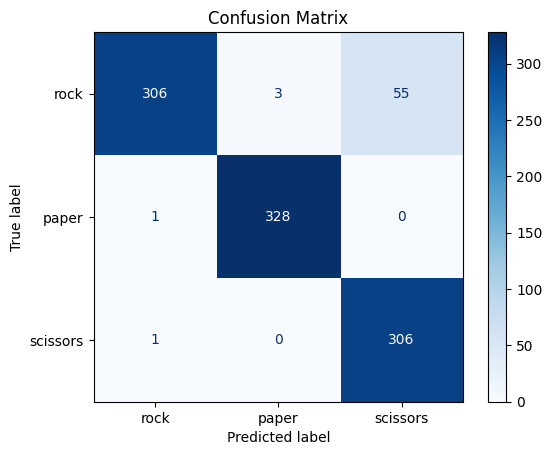

In [57]:
# Accuracy
accuracy = accuracy_score(true_numeric, max_classes)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(true_numeric, max_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(mapping.keys()))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Accuracy (threshold applied): 0.7650 (76.50%)


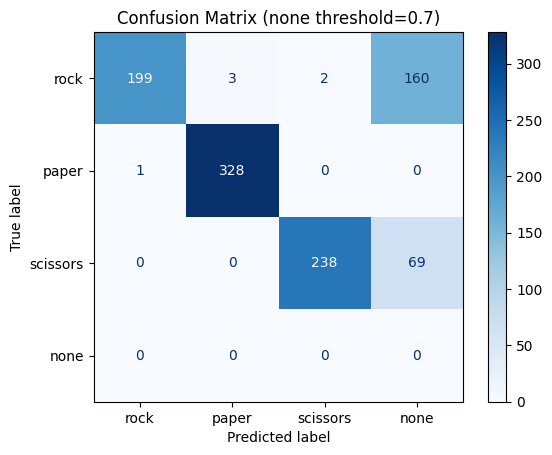

In [58]:
# ------------------------
# Accuracy (threshold applied)
# ------------------------
accuracy_thresh = accuracy_score(true_numeric, pred_classes_thresh)
print(f"Accuracy (threshold applied): {accuracy_thresh:.4f} ({accuracy_thresh*100:.2f}%)")

# ------------------------
# Confusion Matrix with 'none'
# ------------------------
all_labels = list(mapping.keys()) + ['none']  # Include 'none' class

cm_thresh = confusion_matrix(true_numeric, pred_classes_thresh, labels=range(len(all_labels)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_thresh, display_labels=all_labels)
disp.plot(cmap='Blues', xticks_rotation='horizontal')
plt.title(f"Confusion Matrix (none threshold={conf_thres})")
plt.show()

# Evaluation



  FOLD 1 / 5
  Epoch: 0 | Train Loss: 1.11028, Train Acc: 32.20% | Test Loss: 1.10284, Test Acc: 33.50%
  Epoch: 100 | Train Loss: 0.90771, Train Acc: 60.64% | Test Loss: 0.85548, Test Acc: 80.19%
  Epoch: 200 | Train Loss: 0.57889, Train Acc: 73.65% | Test Loss: 0.45273, Test Acc: 86.26%
  Epoch: 300 | Train Loss: 0.45545, Train Acc: 80.38% | Test Loss: 0.31823, Test Acc: 91.85%
  Epoch: 400 | Train Loss: 0.36862, Train Acc: 85.54% | Test Loss: 0.21663, Test Acc: 95.38%
  Epoch: 499 | Train Loss: 0.32028, Train Acc: 88.07% | Test Loss: 0.15711, Test Acc: 97.52%

  FOLD 2 / 5
  Epoch: 0 | Train Loss: 1.11948, Train Acc: 33.32% | Test Loss: 1.11448, Test Acc: 33.68%
  Epoch: 100 | Train Loss: 1.01463, Train Acc: 58.65% | Test Loss: 1.00120, Test Acc: 77.86%
  Epoch: 200 | Train Loss: 0.68660, Train Acc: 72.70% | Test Loss: 0.57706, Test Acc: 87.71%
  Epoch: 300 | Train Loss: 0.52159, Train Acc: 79.20% | Test Loss: 0.37906, Test Acc: 91.46%
  Epoch: 400 | Train Loss: 0.41717, Train Acc:

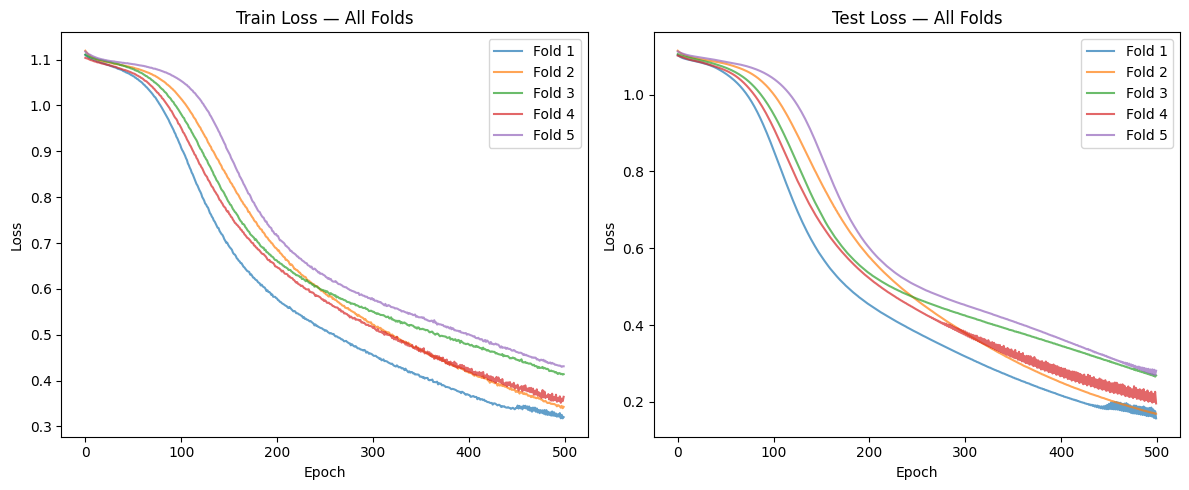


  K-FOLD RESULTS SUMMARY
  Fold 1: Train 88.07%  |  Test 97.52%
  Fold 2: Train 87.19%  |  Test 96.87%
  Fold 3: Train 82.60%  |  Test 93.27%
  Fold 4: Train 86.43%  |  Test 96.66%
  Fold 5: Train 82.85%  |  Test 92.84%

  Mean test acc : 95.43%
  Std  test acc : 1.97%


In [59]:
torch.manual_seed(42)

all_train_losses = [] # Initialize to store epoch-wise train losses for each fold
all_test_losses  = [] # This will now store epoch-wise test losses for each fold

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_train_accs = [] # Initialize to store final train accuracy for each fold
fold_test_accs = [] # This will store final test accuracy for each fold
X_np = X.numpy()
y_np = y.numpy()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"\n{'='*40}")
    print(f"  FOLD {fold + 1} / {N_FOLDS}")
    print(f"{'='*40}")

    # Split data for the current fold
    X_train_fold, y_train_fold = X[train_idx].to(device), y[train_idx].long().to(device)
    X_test_fold, y_test_fold   = X[test_idx].to(device), y[test_idx].long().to(device)

    # Create a new model for each fold to ensure independent training
    model = RPSModel(input_features=input_features,
                     output_features=classes).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1) # Optimizer needs to be re-initialized too

    train_losses_per_epoch_fold = [] # To store losses for current fold's training
    test_losses_per_epoch_fold = []  # To store losses for current fold's testing
    current_fold_train_acc = 0.0
    current_fold_test_acc = 0.0

    for epoch in range(EPOCHS): # Use EPOCHS from ablation cell
        ### Training
        model.train()
        y_logits = model(X_train_fold)
        y_pred = torch.argmax(y_logits, dim=1)
        loss = loss_fn(y_logits, y_train_fold)
        current_fold_train_acc = accuracy_fn(y_true=y_train_fold, y_pred=y_pred)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### Testing (evaluation during training for this fold)
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test_fold)
            test_pred = torch.argmax(test_logits, dim=1)
            test_loss = loss_fn(test_logits, y_test_fold)
            current_fold_test_acc = accuracy_fn(y_true=y_test_fold, y_pred=test_pred)

        train_losses_per_epoch_fold.append(loss.item())
        test_losses_per_epoch_fold.append(test_loss.item())

        if epoch % 100 == 0 or epoch == EPOCHS - 1: # Print less frequently
            print(f"  Epoch: {epoch} | Train Loss: {loss:.5f}, Train Acc: {current_fold_train_acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {current_fold_test_acc:.2f}%")

    # After training for all epochs in a fold, store the epoch-wise losses and final accuracies
    all_train_losses.append(train_losses_per_epoch_fold)
    all_test_losses.append(test_losses_per_epoch_fold)

    fold_train_accs.append(current_fold_train_acc) # acc from last epoch of training
    fold_test_accs.append(current_fold_test_acc) # test_acc from last epoch of testing

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, losses in enumerate(all_train_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Train Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for i, losses in enumerate(all_test_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.7)
plt.title('Test Loss — All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*40}")
print(f"  K-FOLD RESULTS SUMMARY")
print(f"{'='*40}")
for i, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    print(f"  Fold {i+1}: Train {tr:.2f}%  |  Test {te:.2f}%")
print(f"\n  Mean test acc : {np.mean(fold_test_accs):.2f}%")
print(f"  Std  test acc : {np.std(fold_test_accs):.2f}%")

# Which features are the most important?

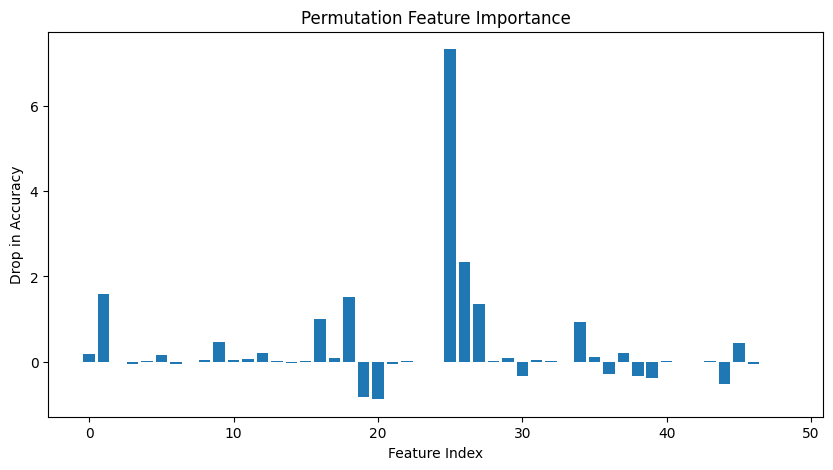

In [60]:
baseline_acc = accuracy_fn(y_true=y_test, y_pred=torch.argmax(model_4(X_test), dim=1))

importances = []
for i in range(X_test.shape[1]):
    X_permuted = X_test.clone()
    X_permuted[:, i] = X_test[torch.randperm(X_test.shape[0]), i]  # shuffle column i

    with torch.inference_mode():
        perm_pred = torch.argmax(model_4(X_permuted), dim=1)

    perm_acc = accuracy_fn(y_true=y_test, y_pred=perm_pred)
    importances.append(baseline_acc - perm_acc)  # drop in accuracy = importance

# Plot
plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Drop in Accuracy")
plt.title("Permutation Feature Importance")
plt.show()

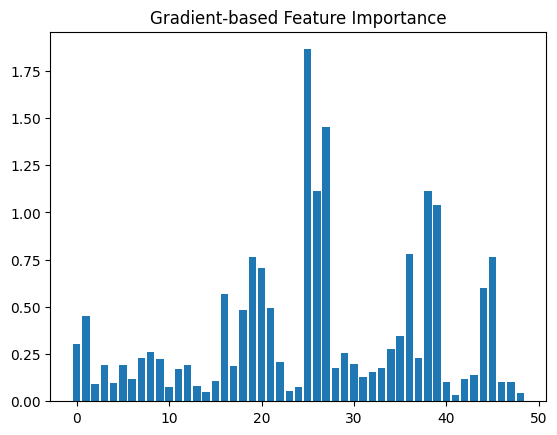

In [61]:
X_test.requires_grad_(True)
output = model_4(X_test)
output.max(dim=1).values.sum().backward()

importances = X_test.grad.abs().mean(dim=0).cpu().detach()

plt.bar(range(len(importances)), importances)
plt.title("Gradient-based Feature Importance")
plt.show()